# 🐧 Clasificación de Pingüinos Palmer
## Exploración progresiva de clasificadores: K-Means -> SVM -> Árbol -> RLM -> Neurona

**Dataset:** Palmer Penguins (seaborn)  
**Objetivo:** Clasificar la especie de pingüino (`Adelie`, `Chinstrap`, `Gentoo`) a partir de sus características físicas  
**Enfoque:** Cada modelo se entrena, evalúa y justifica por qué el siguiente es necesario

---

> 📌 **Estructura:** `Bloque 0` Glosario - `Bloque 1` EDA - `Bloque 2` Preprocesamiento  
> `Bloque 3` K-Means - `Bloque 4` SVM - `Bloque 5` Árbol - `Bloque 6` RLM  
> `Bloque 7` Neurona - `Bloque 8` Comparativa - `Bloque 9` Inferencia - `Bloque 10` Conclusiones

---
## 📖 Bloque 0: Glosario de Términos Clave

| Término | Definición |
|---------|-----------|
| **Feature / Característica** | Variable de entrada usada para predecir (ej: longitud del pico) |
| **Target / Etiqueta** | Variable que queremos predecir (ej: especie del pingüino) |
| **Train / Test** | Train = datos para aprender - Test = datos para evaluar (nunca vistos en entrenamiento) |
| **Normalización (StandardScaler)** | Transforma features a media 0 y desv. estándar 1 para que ninguna variable domine |
| **One-Hot Encoding** | Convierte variables categóricas en columnas binarias (0 o 1) |
| **Overfitting** | El modelo memoriza el dataset de entrenamiento y falla con datos nuevos |
| **Accuracy** | Porcentaje de predicciones correctas sobre el total |
| **F1-Score (Macro)** | Media armónica entre Precision y Recall |
| **Precision** | De todas las veces que predije clase X, ¿cuántas realmente eran X? |
| **Recall** | De todos los ejemplos reales de clase X, ¿cuántos detecté correctamente? |
| **Matriz de Confusión** | Tabla que muestra aciertos y errores por clase. Diagonal = correcto. |
| **Silhouette Score** | Qué tan bien definidos están los clusters (−1 a 1, mayor es mejor) |
| **Kernel (SVM)** | Función que transforma el espacio de features para separar clases no lineales |
| **Softmax** | Convierte salidas numéricas en probabilidades que suman 1 |
| **Backpropagation** | Ajusta pesos en redes neuronales propagando el error hacia atrás |
| **Epoch / Época** | Una pasada completa por todos los datos de entrenamiento |
| **PCA** | Reducción de dimensionalidad para visualizar datos en 2D |

---
## 🎯 El Problema

El dataset **Palmer Penguins** contiene mediciones físicas de 344 pingüinos de 3 especies, recolectadas en el Archipiélago Palmer (Antártida):

- 🐧 **Adelie** -- La más pequeña y abundante; pico corto y redondeado
- 🐧 **Chinstrap** -- Se distingue por la línea negra bajo el mentón
- 🐧 **Gentoo** -- La más grande; pico naranja brillante y aletas largas

### Variables del dataset

| Variable | Tipo | Rol |
|----------|------|-----|
| `species` | Categórica | ✅ **Variable objetivo (target)** |
| `island` | Categórica | Feature -> One-Hot Encoding |
| `bill_length_mm` | Numérica | Feature -> Normalización |
| `bill_depth_mm` | Numérica | Feature -> Normalización |
| `flipper_length_mm` | Numérica | Feature -> Normalización |
| `body_mass_g` | Numérica | Feature -> Normalización |
| `sex` | Categórica | Feature -> One-Hot Encoding |

> 💡 **Analogía:** Este dataset es el equivalente moderno del clásico **Iris Dataset**: features numéricas continuas, 3 clases, tamaño manejable. La diferencia es que Palmer Penguins tiene contexto biológico más rico e intuitivo.

In [17]:
# ============================================================
# IMPORTS
# ============================================================
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Preprocesamiento
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

# Modelos
from sklearn.cluster import KMeans
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier

# Métricas
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, confusion_matrix, classification_report,
    silhouette_score
)

print("✅ Imports cargados correctamente")

✅ Imports cargados correctamente


---
## 📊 Bloque 1: Exploración del Dataset (EDA)

Antes de aplicar cualquier modelo, hay que **conocer los datos**:
- ¿Cuántos registros y columnas tenemos?
- ¿Hay valores faltantes?
- ¿Cómo se distribuyen las clases?
- ¿Qué relación existe entre las variables?

> 🔍 Un modelo entrenado con datos mal entendidos siempre dará resultados pobres -- el EDA no es opcional.

In [18]:
# ── Cargar dataset ─────────────────────────────────────────
df = sns.load_dataset("penguins")

print(f"📐 Dimensiones: {df.shape[0]} filas × {df.shape[1]} columnas")
print(f"\n🔍 Valores nulos por columna:")
print(df.isnull().sum())
print(f"\n📊 Distribución de especies:")
print(df['species'].value_counts())
print(f"\n📋 Tipos de datos:")
print(df.dtypes)

display(df.head())

📐 Dimensiones: 344 filas × 7 columnas

🔍 Valores nulos por columna:
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

📊 Distribución de especies:
species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

📋 Tipos de datos:
species                  str
island                   str
bill_length_mm       float64
bill_depth_mm        float64
flipper_length_mm    float64
body_mass_g          float64
sex                      str
dtype: object


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


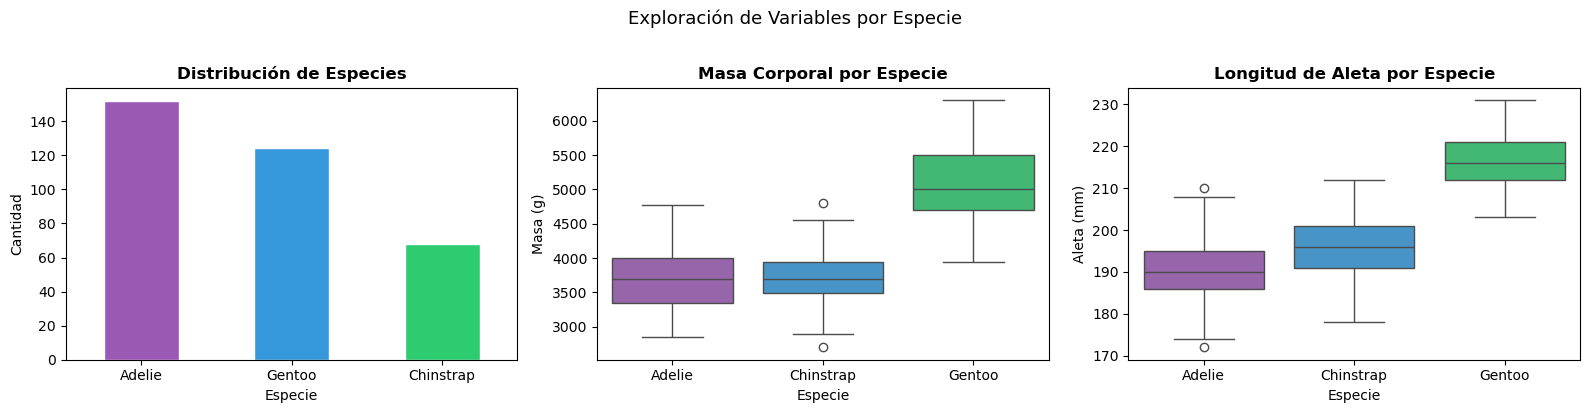


🔗 Relación entre features numéricas...


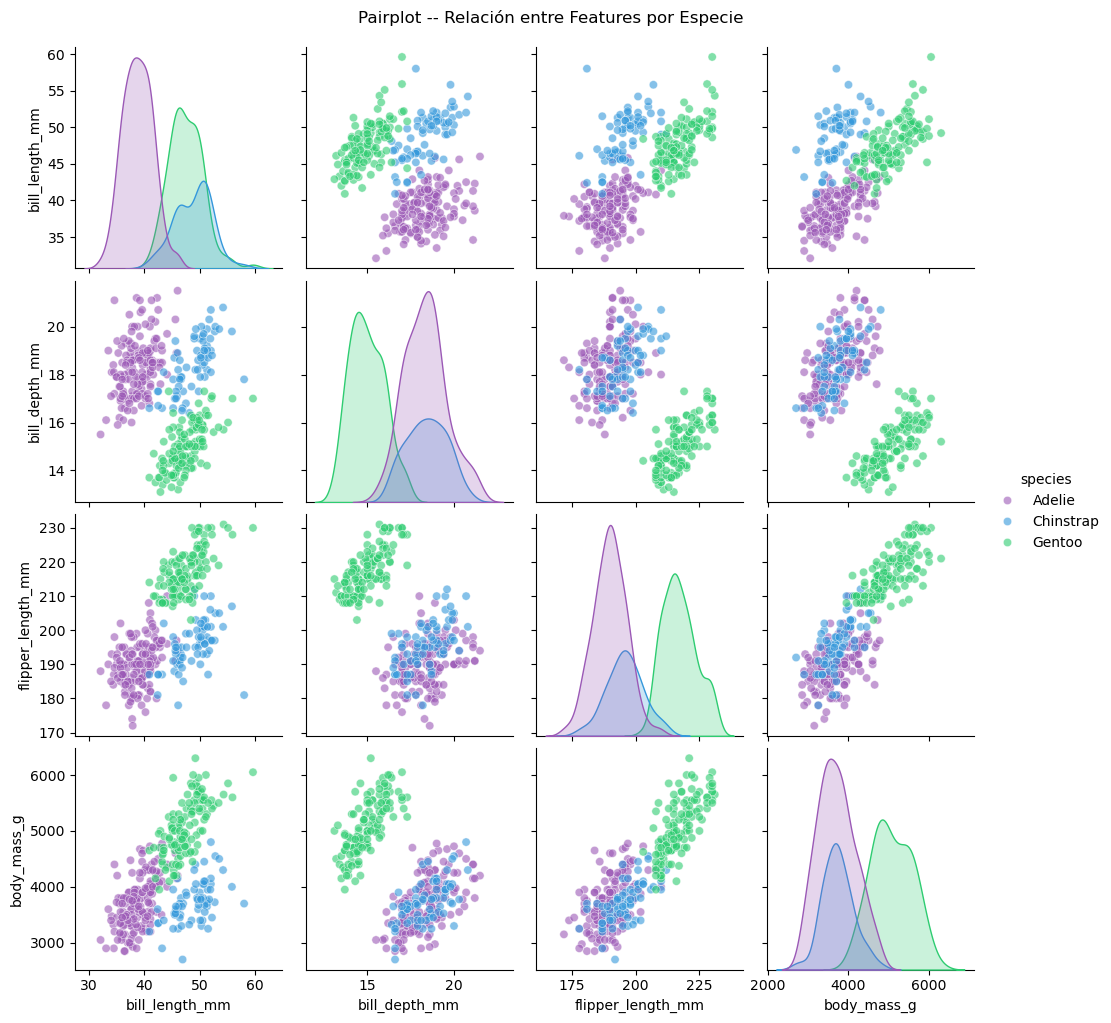

In [19]:
# ── Visualizaciones EDA ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Conteo de especies
df['species'].value_counts().plot(
    kind='bar', ax=axes[0],
    color=['#9b59b6','#3498db','#2ecc71'], edgecolor='white')
axes[0].set_title('Distribución de Especies', fontweight='bold')
axes[0].set_xlabel('Especie'); axes[0].set_ylabel('Cantidad')
axes[0].tick_params(axis='x', rotation=0)

# 2. Masa corporal por especie
sns.boxplot(data=df, x='species', y='body_mass_g',
            palette=['#9b59b6','#3498db','#2ecc71'], ax=axes[1])
axes[1].set_title('Masa Corporal por Especie', fontweight='bold')
axes[1].set_xlabel('Especie'); axes[1].set_ylabel('Masa (g)')

# 3. Longitud de aleta por especie
sns.boxplot(data=df, x='species', y='flipper_length_mm',
            palette=['#9b59b6','#3498db','#2ecc71'], ax=axes[2])
axes[2].set_title('Longitud de Aleta por Especie', fontweight='bold')
axes[2].set_xlabel('Especie'); axes[2].set_ylabel('Aleta (mm)')

plt.suptitle('Exploración de Variables por Especie', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

# ── Pairplot ─────────────────────────────────────────────────
print("\n🔗 Relación entre features numéricas...")
sns.pairplot(df, hue='species',
             vars=['bill_length_mm','bill_depth_mm','flipper_length_mm','body_mass_g'],
             palette=['#9b59b6','#3498db','#2ecc71'],
             plot_kws={'alpha': 0.6}, diag_kind='kde')
plt.suptitle('Pairplot -- Relación entre Features por Especie', y=1.02)
plt.show()

### 🔎 ¿Qué estamos viendo en el EDA?

Antes de correr cualquier modelo, el análisis exploratorio nos da pistas sobre **qué tan difícil será la clasificación** y **qué variables van a importar más**.

Lo que observamos en las gráficas:

- **Gentoo** se separa bastante bien del resto: tiene mayor masa corporal y aletas notablemente más largas. Eso sugiere que los modelos deberían identificarla con relativa facilidad.
- **Adelie** tiende a tener pico más corto y aletas más pequeñas. Se distingue bien de Gentoo, pero hay algo de traslape con Chinstrap.
- **Chinstrap** tiene valores intermedios en masa y aleta, pero su pico es más largo para su tamaño -- esa combinación específica es lo que los modelos deberán aprender a reconocer.

En el pairplot se puede ver que las tres especies forman **nubes de puntos con cierta separación**, lo que es una buena señal: significa que los features contienen información útil para clasificar. Si las nubes estuvieran completamente mezcladas, los modelos tendrían muy poco con qué trabajar.

También existe **correlación positiva entre masa corporal y longitud de aleta** -- a mayor aleta, generalmente mayor masa. Esto es esperable biológicamente, y algunos modelos (como SVM y la neurona) pueden aprovechar esas relaciones entre variables.

> 📌 En resumen: el dataset es **clasificable pero no trivial**. Las especies presentan diferencias claras en algunas variables.

---
## ⚙️ Bloque 2: Preprocesamiento Unificado

Este bloque prepara los datos **una sola vez** para todos los modelos.

### Pasos:
1. **Eliminar NaN** -- los modelos no toleran valores faltantes
2. **Codificar el target** -- `species` -> `0` (Adelie), `1` (Chinstrap), `2` (Gentoo)
3. **One-Hot Encoding** -- `island` y `sex` -> columnas binarias
4. **Train/Test Split** -- 80% entrenamiento, 20% prueba, estratificado
5. **StandardScaler** -- ajustado *solo* con datos de entrenamiento

---

> **¿Por qué eliminamos NaN en lugar de reemplazarlos con 0?**  
> Porque aquí los NaN son mediciones físicas: longitud del pico, masa corporal, largo de aleta.  
> Poner `0` significaría "este pingüino tiene pico de 0 mm y pesa 0 gramos" -- un dato imposible que el modelo tomaría como real y aprendería basura.  
>
> La alternativa correcta a eliminarlos sería **imputar con la media o mediana** de la especie.  
> Sin embargo, con solo **11 filas faltantes de 344 (~3%)**, eliminarlas es viable -- no perdemos información significativa.

---

> **¿Por qué escalar DESPUÉS del split?**  
> Si ajustamos el scaler con *todos* los datos, el modelo "vería" información del test durante el entrenamiento -- eso es **data leakage** y produce métricas artificialmente optimistas.

In [20]:
# ── 1. Limpiar NaN ──────────────────────────────────────────
df_clean = df.dropna().reset_index(drop=True)
print(f"✅ Filas originales: {len(df)} | Después de limpiar NaN: {len(df_clean)} ({len(df)-len(df_clean)} eliminadas)")

# ── 2. Codificar target ─────────────────────────────────────
le = LabelEncoder()
y = le.fit_transform(df_clean['species'])
class_names = le.classes_
print(f"\n🏷️  Codificación: {dict(enumerate(class_names))}")

# ── 3. One-Hot Encoding ─────────────────────────────────────
df_features = df_clean.drop(columns=['species'])
df_encoded  = pd.get_dummies(df_features, columns=['island', 'sex'], drop_first=False)
feature_names = df_encoded.columns.tolist()
print(f"\n📋 Features tras encoding ({len(feature_names)} columnas): {feature_names}")

# ── 4. Convertir a numpy ────────────────────────────────────
X_raw = df_encoded.values.astype(float)

# ── 5. Split antes de escalar ───────────────────────────────
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42, stratify=y
)

# ── 6. Escalar solo con train ───────────────────────────────
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test  = scaler.transform(X_test_raw)

print(f"\n📐 Train: {X_train.shape} | Test: {X_test.shape}")
print(f"📊 Clases en train: {dict(zip(class_names, np.bincount(y_train)))}")
print(f"📊 Clases en test:  {dict(zip(class_names, np.bincount(y_test)))}")

✅ Filas originales: 344 | Después de limpiar NaN: 333 (11 eliminadas)

🏷️  Codificación: {0: 'Adelie', 1: 'Chinstrap', 2: 'Gentoo'}

📋 Features tras encoding (9 columnas): ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'island_Biscoe', 'island_Dream', 'island_Torgersen', 'sex_Female', 'sex_Male']

📐 Train: (266, 9) | Test: (67, 9)
📊 Clases en train: {'Adelie': np.int64(117), 'Chinstrap': np.int64(54), 'Gentoo': np.int64(95)}
📊 Clases en test:  {'Adelie': np.int64(29), 'Chinstrap': np.int64(14), 'Gentoo': np.int64(24)}


In [21]:
# ============================================================
# FUNCIONES AUXILIARES REUTILIZABLES
# ============================================================

resultados = {}   # Acumula métricas para la tabla comparativa final

def plot_confusion_matrix(y_true, y_pred, title):
    """Grafica la matriz de confusión y explica cómo leerla."""
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_xlabel('Predicción', fontsize=12)
    ax.set_ylabel('Real', fontsize=12)
    ax.set_title(title, fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

    # ── Interpretación automática ───────────────────────────
    diagonal = np.diag(cm)
    total    = cm.sum()
    aciertos = diagonal.sum()
    print("\n📌 ¿Cómo leer la matriz de confusión?")
    print("   La diagonal principal = predicciones correctas.")
    print("   Valores fuera de la diagonal = errores (confusión entre clases).")
    print(f"   Total aciertos: {aciertos}/{total} ({aciertos/total*100:.1f}%)")
    for i, cls in enumerate(class_names):
        errores = cm[i].sum() - cm[i, i]
        print(f"   - {cls}: {cm[i,i]} correctos, {errores} errores")


def print_metrics(y_true, y_pred, model_name):
    """Imprime métricas, las interpreta y las guarda en 'resultados'."""
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average='macro')
    pre = precision_score(y_true, y_pred, average='macro')
    rec = recall_score(y_true, y_pred, average='macro')

    print(f"\n{'═'*52}")
    print(f"  📈 Métricas -- {model_name}")
    print(f"{'═'*52}")
    print(f"  Accuracy  : {acc:.4f}  ({acc*100:.1f}%)")
    print(f"  F1-Macro  : {f1:.4f}")
    print(f"  Precision : {pre:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"{'═'*52}")
    print()
    print("  📌 ¿Qué significan estas métricas?")
    print(f"  - Accuracy {acc*100:.1f}%: de cada 100 pingüinos, el modelo acierta ~{int(acc*100)}.")
    print(f"  - Precision {pre:.2f}: cuando predice una especie, acierta el {pre*100:.0f}% de las veces.")
    print(f"  - Recall {rec:.2f}: detecta el {rec*100:.0f}% de los casos reales de cada especie.")
    print(f"  - F1 {f1:.2f}: balance general entre precision y recall.")
    if acc >= 0.95:
        print("  ✅ Desempeño excelente para este dataset.")
    elif acc >= 0.85:
        print("  ✅ Buen desempeño, con margen de mejora.")
    else:
        print("  ⚠️  Desempeño limitado -- este modelo tiene dificultades con estos datos.")

    resultados[model_name] = {
        'Accuracy':  round(acc, 4),
        'F1-Macro':  round(f1, 4),
        'Precision': round(pre, 4),
        'Recall':    round(rec, 4)
    }
    return acc, f1


print("✅ Funciones auxiliares listas")

✅ Funciones auxiliares listas


---
## 🔵 Bloque 3: K-Means

### ¿Qué es K-Means?
K-Means es **aprendizaje no supervisado** -- no usa etiquetas durante el entrenamiento.  
Agrupa los datos en **K clusters** minimizando la distancia de cada punto al centroide de su cluster.

### ¿Cómo funciona?
1. Se inicializan K centroides (aleatoriamente o con k-means++)
2. Cada punto se asigna al centroide más cercano (distancia euclidiana)
3. Los centroides se recalculan como el promedio de sus puntos
4. Se repite hasta convergencia

### ¿Por qué empezamos aquí?
Queremos ver si las especies se separan **naturalmente** en el espacio de features sin usar etiquetas. Es el punto de partida más honesto: ¿los datos solos son suficientemente separables?

### Métricas para clustering
- **Silhouette Score** (−1 a 1): qué tan compactos y separados están los clusters.
- **Inercia**: suma de distancias al cuadrado al centroide. Menor = más compacto.

📐 Silhouette Score : 0.3975  (1.0 = clusters perfectos)
📐 Inercia (train)  : 1079.49

════════════════════════════════════════════════════
  📈 Métricas -- K-Means
════════════════════════════════════════════════════
  Accuracy  : 0.7910  (79.1%)
  F1-Macro  : 0.6019
  Precision : 0.5581
  Recall    : 0.6667
════════════════════════════════════════════════════

  📌 ¿Qué significan estas métricas?
  - Accuracy 79.1%: de cada 100 pingüinos, el modelo acierta ~79.
  - Precision 0.56: cuando predice una especie, acierta el 56% de las veces.
  - Recall 0.67: detecta el 67% de los casos reales de cada especie.
  - F1 0.60: balance general entre precision y recall.
  ⚠️  Desempeño limitado -- este modelo tiene dificultades con estos datos.


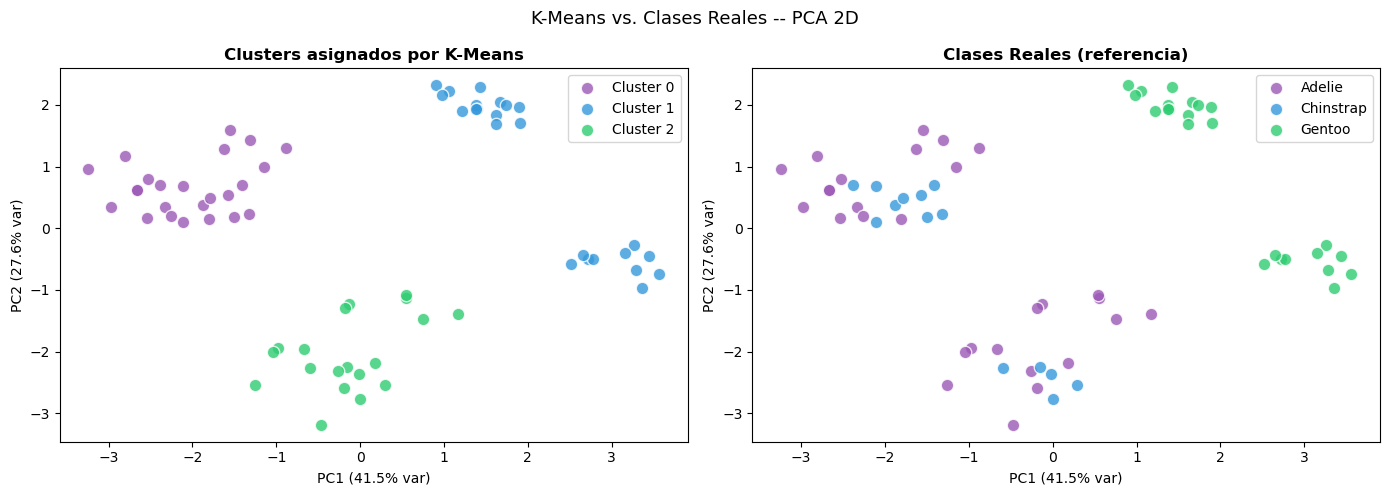

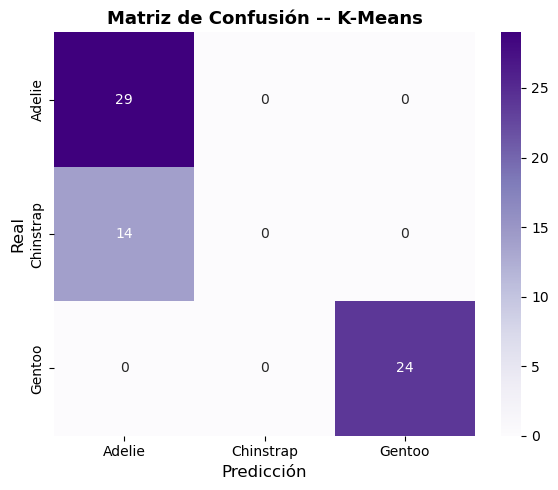


📌 ¿Cómo leer la matriz de confusión?
   La diagonal principal = predicciones correctas.
   Valores fuera de la diagonal = errores (confusión entre clases).
   Total aciertos: 53/67 (79.1%)
   - Adelie: 29 correctos, 0 errores
   - Chinstrap: 0 correctos, 14 errores
   - Gentoo: 24 correctos, 0 errores


In [22]:
# ── Entrenamiento K-Means ───────────────────────────────────
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(X_train)

clusters_test = kmeans.predict(X_test)

# ── Mapear clusters ────────────────────────
# K-Means asigna etiquetas arbitrarias (0,1,2) sin saber cuál especie es cuál.
# Mapeamos cada cluster a la clase real más frecuente dentro de él.
# (Esto es un truco para evaluación -- en producción real no tendríamos y_test)
label_map = {}
for cluster_id in range(3):
    mask = clusters_test == cluster_id
    if mask.sum() > 0:
        label_map[cluster_id] = int(np.bincount(y_test[mask]).argmax())
    else:
        label_map[cluster_id] = cluster_id

y_pred_kmeans = np.array([label_map[c] for c in clusters_test])

# ── Métricas ────────────────────────────────────────────────
sil = silhouette_score(X_test, clusters_test)
print(f"📐 Silhouette Score : {sil:.4f}  (1.0 = clusters perfectos)")
print(f"📐 Inercia (train)  : {kmeans.inertia_:.2f}")

print_metrics(y_test, y_pred_kmeans, "K-Means")

# ── Visualización PCA 2D ─────────────────────────────────────
pca = PCA(n_components=2, random_state=42)
X_test_2d = pca.fit_transform(X_test)
palette = ['#9b59b6', '#3498db', '#2ecc71']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i in range(3):
    mask = clusters_test == i
    axes[0].scatter(X_test_2d[mask, 0], X_test_2d[mask, 1],
                    c=palette[i], label=f'Cluster {i}', alpha=0.8, edgecolors='white', s=80)
axes[0].set_title('Clusters asignados por K-Means', fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
axes[0].legend()

for i, name in enumerate(class_names):
    mask = y_test == i
    axes[1].scatter(X_test_2d[mask, 0], X_test_2d[mask, 1],
                    c=palette[i], label=name, alpha=0.8, edgecolors='white', s=80)
axes[1].set_title('Clases Reales (referencia)', fontweight='bold')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
axes[1].legend()

plt.suptitle('K-Means vs. Clases Reales -- PCA 2D', fontsize=13)
plt.tight_layout(); plt.show()

plot_confusion_matrix(y_test, y_pred_kmeans, "Matriz de Confusión -- K-Means")

### ⚠️ Limitaciones de K-Means -> ¿Por qué necesitamos algo más?

1. **No supervisado:** No usa las etiquetas reales. El mapeo cluster -> especie que hicimos es un truco manual que en producción real no podríamos hacer.
2. **Asume clusters esféricos:** Minimiza distancias euclidianas, lo que lo sesga hacia clusters de tamaño y forma similares.
3. **No predice con certeza:** Solo asigna grupos, sin probabilidades ni garantías basadas en aprendizaje supervisado.

> 💡 **Siguiente paso:** Usemos las etiquetas reales para encontrar el **hiperplano óptimo** que separe las clases con máximo margen -- **SVM**.

---
## 🔴 Bloque 4: Support Vector Machine (SVM)

### ¿Qué es SVM?
SVM busca el **hiperplano óptimo** que maximiza el margen entre las clases. Con `kernel='rbf'` aplica una transformación gaussiana para capturar relaciones no lineales.

### ¿Cómo funciona?
1. Identifica los puntos más cercanos al límite de decisión (**vectores de soporte**)
2. Maximiza la distancia (margen) entre esos puntos y el hiperplano
3. Con kernel RBF: transforma el espacio de features a mayor dimensión donde las clases sí son separables

### Parámetros clave
- **C**: trade-off entre margen máximo y errores. C alto = menos errores de train, más riesgo de overfitting.
- **gamma='scale'**: radio de influencia de cada vector de soporte, ajustado automáticamente.

### Ventajas sobre K-Means
- ✅ Supervisado: aprende directamente de las etiquetas reales
- ✅ Robusto al overfitting gracias al principio de margen máximo


════════════════════════════════════════════════════
  📈 Métricas -- SVM (kernel RBF)
════════════════════════════════════════════════════
  Accuracy  : 0.9851  (98.5%)
  F1-Macro  : 0.9827
  Precision : 0.9778
  Recall    : 0.9885
════════════════════════════════════════════════════

  📌 ¿Qué significan estas métricas?
  - Accuracy 98.5%: de cada 100 pingüinos, el modelo acierta ~98.
  - Precision 0.98: cuando predice una especie, acierta el 98% de las veces.
  - Recall 0.99: detecta el 99% de los casos reales de cada especie.
  - F1 0.98: balance general entre precision y recall.
  ✅ Desempeño excelente para este dataset.


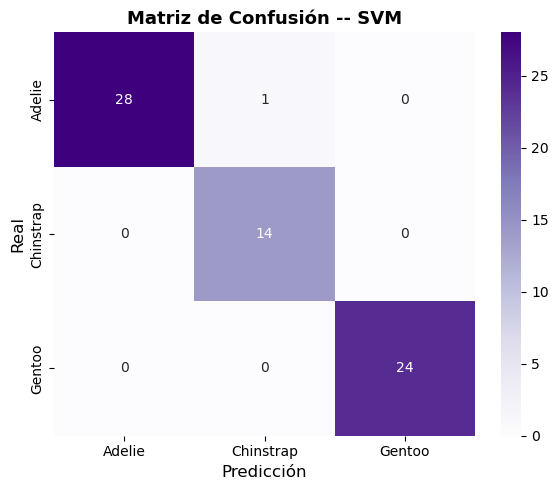


📌 ¿Cómo leer la matriz de confusión?
   La diagonal principal = predicciones correctas.
   Valores fuera de la diagonal = errores (confusión entre clases).
   Total aciertos: 66/67 (98.5%)
   - Adelie: 28 correctos, 1 errores
   - Chinstrap: 14 correctos, 0 errores
   - Gentoo: 24 correctos, 0 errores

📋 Reporte detallado por clase:
              precision    recall  f1-score   support

      Adelie       1.00      0.97      0.98        29
   Chinstrap       0.93      1.00      0.97        14
      Gentoo       1.00      1.00      1.00        24

    accuracy                           0.99        67
   macro avg       0.98      0.99      0.98        67
weighted avg       0.99      0.99      0.99        67



In [23]:
# ── Entrenamiento SVM ───────────────────────────────────────
svm = SVC(
    kernel='rbf',        # Kernel gaussiano -- relaciones no lineales
    C=1.0,               # Regularización estándar
    gamma='scale',       # Ajuste automático de gamma
    random_state=42,
    probability=True     # Activa predict_proba (necesario para inferencia)
)
svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

print_metrics(y_test, y_pred_svm, "SVM (kernel RBF)")
plot_confusion_matrix(y_test, y_pred_svm, "Matriz de Confusión -- SVM")

print("\n📋 Reporte detallado por clase:")
print(classification_report(y_test, y_pred_svm, target_names=class_names))

### ⚠️ Limitaciones de SVM -> ¿Por qué necesitamos algo más?

1. **Caja negra:** El hiperplano no es intuitivo. Si alguien pregunta "¿por qué clasificó como Gentoo?", SVM no da una respuesta en términos de las features originales.
2. **No interpretable:** No hay reglas del tipo "si aleta > 210 mm entonces es Gentoo".
3. **Requiere normalización estricta:** Muy sensible a la escala de las features.

> 💡 **Siguiente paso:** Necesitamos un modelo **completamente interpretable** con reglas de decisión claras y visualizables -- **Árbol de Decisión**.

---
## 🟢 Bloque 5: Árbol de Decisión

### ¿Qué es un Árbol de Decisión?
Aprende **reglas if-then-else** sobre las features para clasificar. Es uno de los modelos más interpretables: puedes seguir el camino de cualquier predicción.

### ¿Cómo funciona?
1. En la raíz, selecciona el feature y umbral que mejor **reduce la impureza Gini**
2. Divide los datos en dos subconjuntos
3. Repite recursivamente hasta nodos puros o límite de profundidad

### Impureza de Gini
`Gini = 1 − Σ p²ᵢ` (pᵢ = proporción de cada clase en el nodo)  
Gini = 0 -> nodo puro (una sola clase) - Gini -> 0.67 -> clases completamente mezcladas

### Ventajas sobre SVM
- ✅ 100% interpretable: cada predicción sigue un camino de reglas legibles
- ✅ No requiere normalización
- ✅ Visualizable como diagrama


════════════════════════════════════════════════════
  📈 Métricas -- Árbol de Decisión
════════════════════════════════════════════════════
  Accuracy  : 0.9552  (95.5%)
  F1-Macro  : 0.9518
  Precision : 0.9468
  Recall    : 0.9607
════════════════════════════════════════════════════

  📌 ¿Qué significan estas métricas?
  - Accuracy 95.5%: de cada 100 pingüinos, el modelo acierta ~95.
  - Precision 0.95: cuando predice una especie, acierta el 95% de las veces.
  - Recall 0.96: detecta el 96% de los casos reales de cada especie.
  - F1 0.95: balance general entre precision y recall.
  ✅ Desempeño excelente para este dataset.


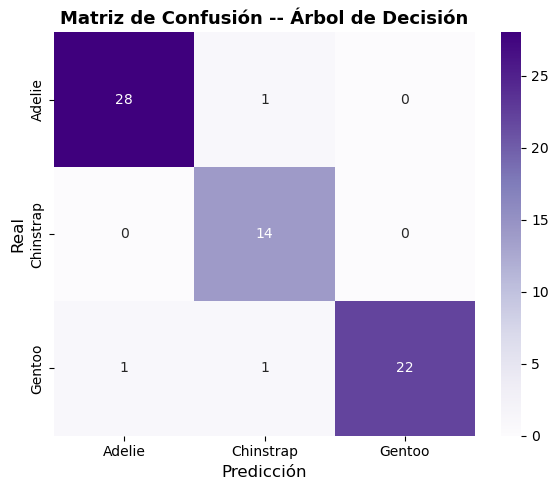


📌 ¿Cómo leer la matriz de confusión?
   La diagonal principal = predicciones correctas.
   Valores fuera de la diagonal = errores (confusión entre clases).
   Total aciertos: 64/67 (95.5%)
   - Adelie: 28 correctos, 1 errores
   - Chinstrap: 14 correctos, 0 errores
   - Gentoo: 22 correctos, 2 errores


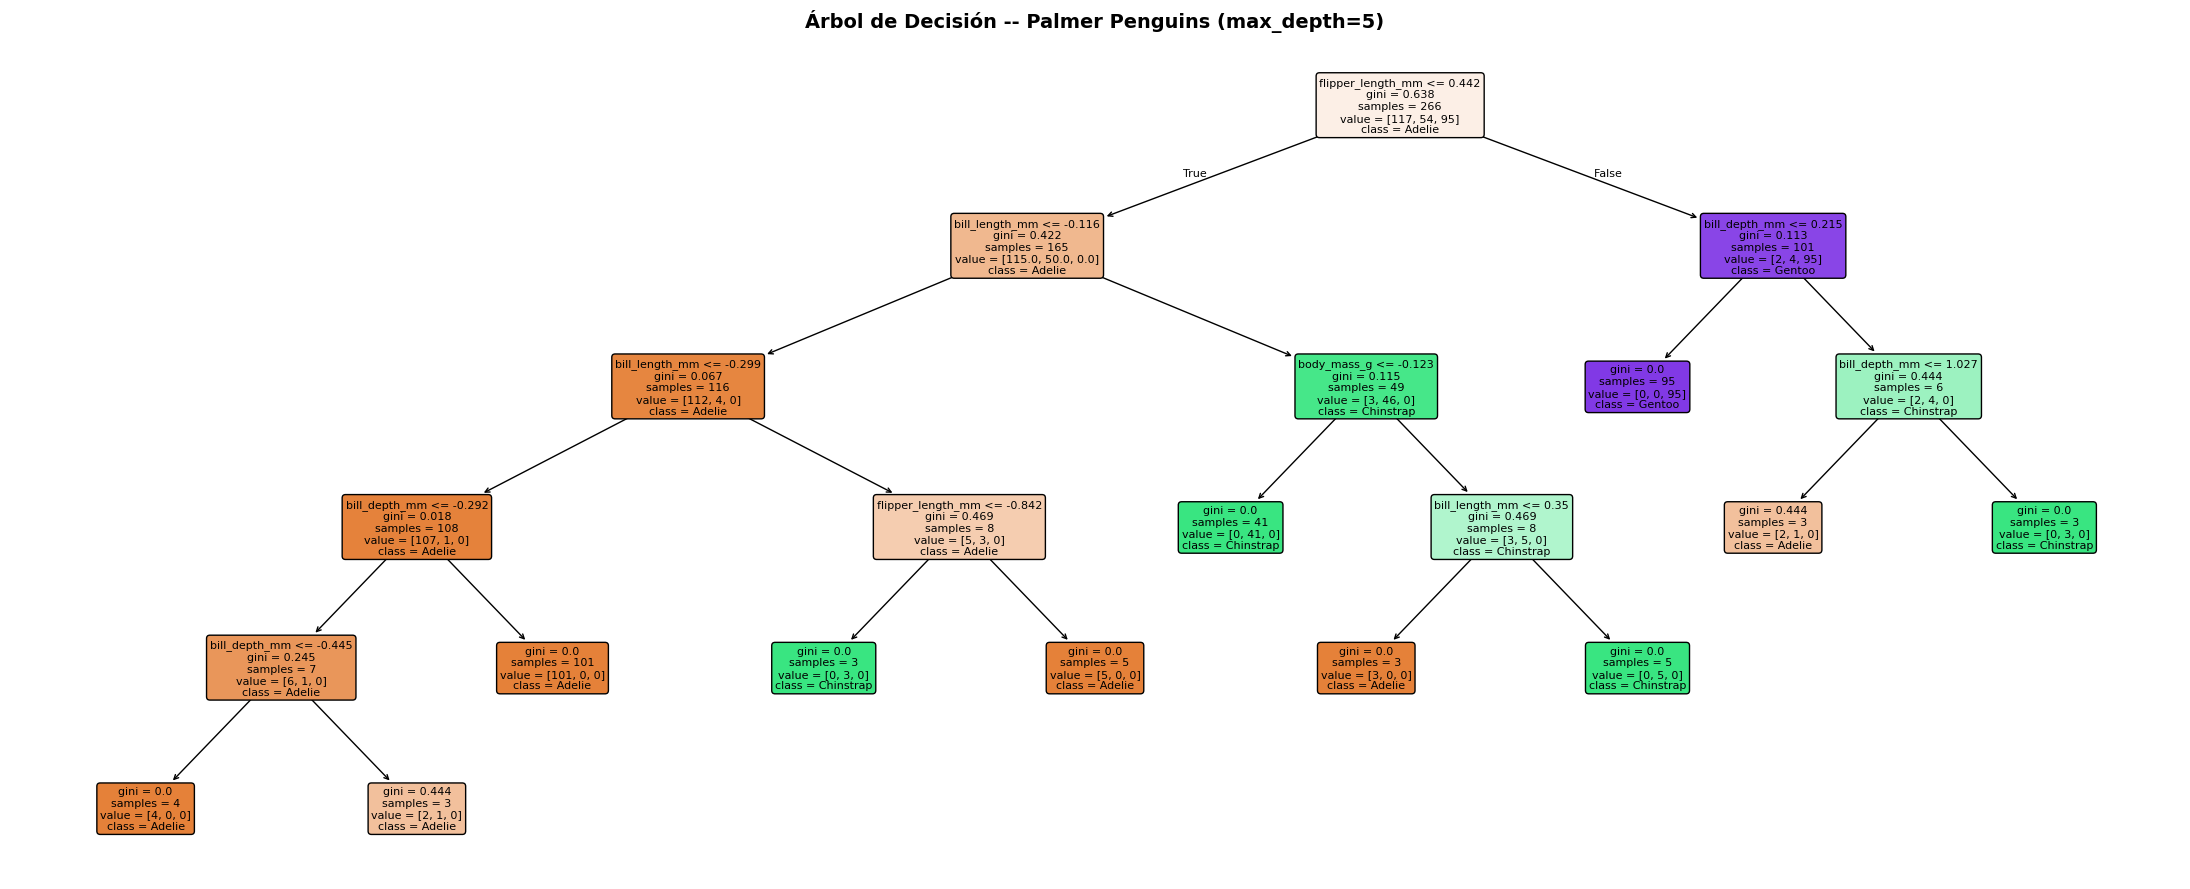

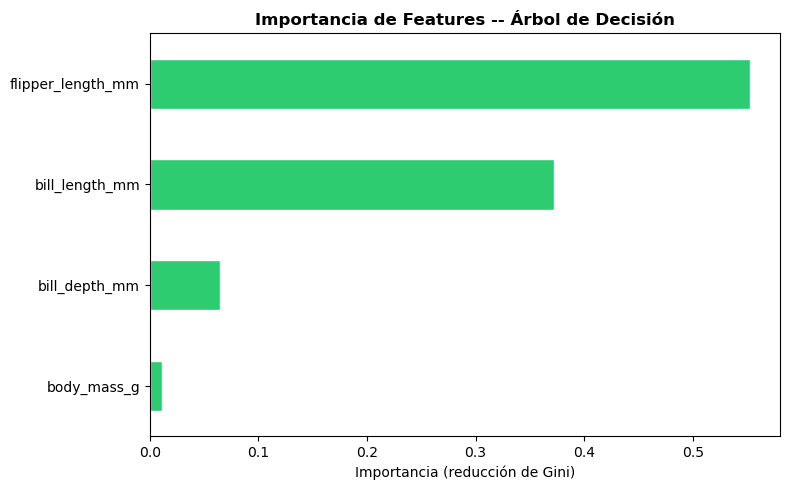


📌 Interpretación de importancia de features:
   La variable más determinante fue 'flipper_length_mm' (0.552).
   Las features con importancia 0 no participaron en ningún split del árbol.

🌳 Profundidad real: 5 | Hojas: 11


In [24]:
# ── Entrenamiento Árbol de Decisión ─────────────────────────
arbol = DecisionTreeClassifier(
    max_depth=5,           # Límite de profundidad para controlar overfitting
    criterion='gini',      # Impureza de Gini como criterio de split
    min_samples_leaf=3,    # Mínimo de muestras en cada hoja
    random_state=42
)
arbol.fit(X_train, y_train)

y_pred_arbol = arbol.predict(X_test)

print_metrics(y_test, y_pred_arbol, "Árbol de Decisión")
plot_confusion_matrix(y_test, y_pred_arbol, "Matriz de Confusión -- Árbol de Decisión")

# ── Visualizar el árbol ──────────────────────────────────────
plt.figure(figsize=(22, 9))
plot_tree(arbol, feature_names=feature_names, class_names=class_names,
          filled=True, rounded=True, fontsize=8, impurity=True)
plt.title("Árbol de Decisión -- Palmer Penguins (max_depth=5)", fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

# ── Importancia de features ─────────────────────────────────
importances = pd.Series(arbol.feature_importances_, index=feature_names)
importances_sorted = importances[importances > 0].sort_values()

plt.figure(figsize=(8, 5))
importances_sorted.plot(kind='barh', color='#2ecc71', edgecolor='white')
plt.title('Importancia de Features -- Árbol de Decisión', fontweight='bold')
plt.xlabel('Importancia (reducción de Gini)')
plt.tight_layout(); plt.show()

# ── Interpretación de importancia ───────────────────────────
top_feature = importances.idxmax()
top_val     = importances.max()
print(f"\n📌 Interpretación de importancia de features:")
print(f"   La variable más determinante fue '{top_feature}' ({top_val:.3f}).")
print("   Las features con importancia 0 no participaron en ningún split del árbol.")
print(f"\n🌳 Profundidad real: {arbol.get_depth()} | Hojas: {arbol.get_n_leaves()}")

### ⚠️ Limitaciones del Árbol -> ¿Por qué necesitamos algo más?

1. **Overfitting latente:** Sin restricciones memoriza el entrenamiento. `max_depth=5` lo controla, pero no elimina el riesgo.
2. **Fronteras rectangulares:** Siempre "mayor/menor que un umbral" -- no captura bien bordes curvos.
3. **Probabilidades poco confiables:** Reporta la proporción de la hoja, no una estimación probabilística real.

> 💡 **Siguiente paso:** Necesitamos un modelo que produzca **probabilidades calibradas y reales** -- **Regresión Logística Multinomial**.

---
## 🟠 Bloque 6: Regresión Logística Multinomial (RLM)

### ¿Qué es?
A pesar del nombre "regresión", es un **clasificador probabilístico**. Usa la función **softmax** para convertir combinaciones lineales de features en probabilidades reales que suman 1.

### ¿Cómo funciona?
1. Para cada clase k: `zₖ = w₁ₖ-x₁ + w₂ₖ-x₂ + ... + bₖ`
2. Softmax: `P(clase k | x) = exp(zₖ) / Σⱼ exp(zⱼ)`
3. Predice la clase con mayor probabilidad
4. Se entrena minimizando la **entropía cruzada** (cross-entropy loss)

### ¿Por qué es "lineal"?
Las fronteras de decisión entre clases son **hiperplanos lineales**. Si los datos requieren fronteras curvas, el modelo tiene dificultades.

### Ventajas sobre el Árbol
- ✅ Probabilidades calibradas y reales
- ✅ Más estable ante cambios en los datos
- ✅ Coeficientes interpretables: indican la influencia de cada feature


════════════════════════════════════════════════════
  📈 Métricas -- Regresión Logística Multinomial
════════════════════════════════════════════════════
  Accuracy  : 0.9851  (98.5%)
  F1-Macro  : 0.9827
  Precision : 0.9778
  Recall    : 0.9885
════════════════════════════════════════════════════

  📌 ¿Qué significan estas métricas?
  - Accuracy 98.5%: de cada 100 pingüinos, el modelo acierta ~98.
  - Precision 0.98: cuando predice una especie, acierta el 98% de las veces.
  - Recall 0.99: detecta el 99% de los casos reales de cada especie.
  - F1 0.98: balance general entre precision y recall.
  ✅ Desempeño excelente para este dataset.


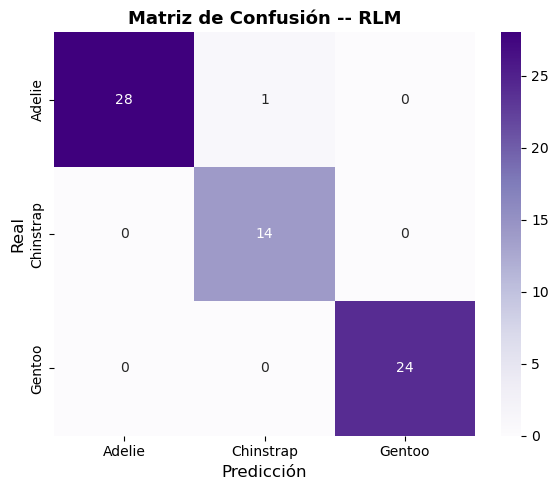


📌 ¿Cómo leer la matriz de confusión?
   La diagonal principal = predicciones correctas.
   Valores fuera de la diagonal = errores (confusión entre clases).
   Total aciertos: 66/67 (98.5%)
   - Adelie: 28 correctos, 1 errores
   - Chinstrap: 14 correctos, 0 errores
   - Gentoo: 24 correctos, 0 errores

🎲 Probabilidades predichas (primeras 8 muestras del test):


,Real,Predicción,Adelie,Chinstrap,Gentoo,✓
0,Gentoo,Gentoo,0.0002,0.0116,0.9882,True
1,Chinstrap,Chinstrap,0.0231,0.9703,0.0066,True
2,Adelie,Adelie,0.9904,0.0088,0.0009,True
3,Gentoo,Gentoo,0.0005,0.0042,0.9953,True
4,Gentoo,Gentoo,0.0009,0.0073,0.9918,True
5,Gentoo,Gentoo,0.0164,0.0028,0.9808,True
6,Chinstrap,Chinstrap,0.0086,0.9882,0.0032,True
7,Adelie,Adelie,0.9991,0.0001,0.0008,True



⚖️  Coeficientes por clase:


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,island_Biscoe,island_Dream,island_Torgersen,sex_Female,sex_Male
Adelie,-2.336,0.803,-0.615,-0.262,0.030,-0.320,0.395,-0.390,0.390
Chinstrap,1.919,0.191,-0.251,-0.564,-0.686,0.884,-0.239,0.322,-0.322
Gentoo,0.417,-0.993,0.866,0.826,0.656,-0.564,-0.156,0.068,-0.068



=== Como leer los coeficientes? ===
Los coeficientes indican cuanto contribuye cada variable
a la probabilidad de pertenecer a cada especie:

  - Valor positivo: aumenta la probabilidad de esa especie
  - Valor negativo: la reduce
  - Mayor magnitud: mayor influencia en la decision

Las variables con coeficientes grandes en Gentoo
coinciden con lo visto en el EDA: mayor masa y aletas largas.

Ventaja frente al Arbol: las probabilidades son reales
y calibradas, no solo proporciones de una hoja.


In [25]:
# ── Entrenamiento Regresión Logística Multinomial ────────────
# El solver 'lbfgs' maneja automáticamente la clasificación multinomial.
rlm = LogisticRegression(
    solver='lbfgs',    # Optimizador adecuado para softmax multinomial
    max_iter=1000,     # Suficientes iteraciones para convergencia
    C=1.0,             # Inverso de regularización L2 (1.0 = estándar)
    random_state=42
)
rlm.fit(X_train, y_train)

y_pred_rlm = rlm.predict(X_test)
y_prob_rlm = rlm.predict_proba(X_test)   # Probabilidades reales por clase

# ── Métricas ────────────────────────────────────────────────
print_metrics(y_test, y_pred_rlm, "Regresión Logística Multinomial")
plot_confusion_matrix(y_test, y_pred_rlm, "Matriz de Confusión -- RLM")

# ── Probabilidades de las primeras predicciones ─────────────
print("\n🎲 Probabilidades predichas (primeras 8 muestras del test):")
prob_df = pd.DataFrame(y_prob_rlm[:8], columns=class_names).round(4)
prob_df.insert(0, 'Real',       [class_names[r] for r in y_test[:8]])
prob_df.insert(1, 'Predicción', [class_names[p] for p in y_pred_rlm[:8]])
prob_df['✓'] = prob_df['Real'] == prob_df['Predicción']
display(prob_df)

# ── Coeficientes del modelo ──────────────────────────────────
print("\n⚖️  Coeficientes por clase:")
coef_df = pd.DataFrame(rlm.coef_, columns=feature_names, index=class_names)
display(coef_df.round(3))

# ── Interpretación de coeficientes ──────────────────────────
# -- Interpretacion de coeficientes
print(
    "\n=== Como leer los coeficientes? ===\n"
    "Los coeficientes indican cuanto contribuye cada variable\n"
    "a la probabilidad de pertenecer a cada especie:\n\n"
    "  - Valor positivo: aumenta la probabilidad de esa especie\n"
    "  - Valor negativo: la reduce\n"
    "  - Mayor magnitud: mayor influencia en la decision\n\n"
    "Las variables con coeficientes grandes en Gentoo\n"
    "coinciden con lo visto en el EDA: mayor masa y aletas largas.\n\n"
    "Ventaja frente al Arbol: las probabilidades son reales\n"
    "y calibradas, no solo proporciones de una hoja."
)


### ⚠️ Limitaciones de RLM -> ¿Por qué necesitamos algo más?

1. **Linealidad estricta:** Las fronteras de decisión son hiperplanos. Si la separación real requiere curvas, RLM no puede aprenderlas.
2. **No aprende representaciones:** Usa las features tal como son, sin crear variables latentes que capturen patrones más abstractos.
3. **Interacciones entre features:** No modela automáticamente combinaciones complejas entre variables.

> 💡 **Siguiente paso:** Para capturar **relaciones no lineales** y aprender representaciones intermedias, necesitamos capas ocultas -- **Red Neuronal (MLP)**.

---
## 🟣 Bloque 7: Red Neuronal -- Perceptrón Multicapa (MLP)

### ¿Qué es un MLP?
Una red neuronal con capas ocultas que aprenden representaciones intermedias y no lineales:

```
Entrada (11) -> Oculta (64, ReLU) -> Oculta (32, ReLU) -> Salida (3, Softmax)
```

### ¿Cómo aprende?
1. **Forward pass:** datos fluyen capa a capa: `output = activación(W-x + b)`
2. **Loss:** se calcula el error entre predicción y etiqueta real (cross-entropy)
3. **Backpropagation:** el error se propaga hacia atrás calculando gradientes
4. **Adam optimizer:** ajusta pesos y biases para minimizar el error
5. Se repite por épocas hasta convergencia

---

> 💡 **Nota -- Complejidad de implementar esto desde cero (estilo McCulloch-Pitts):**
>
> Implementar este MLP manualmente implicaría:
> - Matrices de pesos `W₁` (11×64), `W₂` (64×32), `W₃` (32×3) con inicialización controlada
> - Programar ReLU: `f(x) = max(0, x)` y softmax desde cero como funciones Python
> - Implementar **backpropagation completo**: calcular ∂Loss/∂W₃ -> ∂Loss/∂W₂ -> ∂Loss/∂W₁ usando la regla de la cadena en cada capa
> - Programar Adam con sus momentos de primer y segundo orden
> - Gestionar el ciclo de épocas, mini-batches y early stopping
>
> Esto es viable para **1 neurona con salida binaria** (como en el ejercicio de McCulloch-Pitts con el dataset de cáncer de mama), pero para una red con 2 capas ocultas, 3 clases y 11 features, la complejidad se vuelve prohibitiva sin abstracciones.
> `MLPClassifier` de sklearn realiza exactamente todo eso internamente.


════════════════════════════════════════════════════
  📈 Métricas -- Red Neuronal (MLP)
════════════════════════════════════════════════════
  Accuracy  : 0.9701  (97.0%)
  F1-Macro  : 0.9632
  Precision : 0.9785
  Recall    : 0.9524
════════════════════════════════════════════════════

  📌 ¿Qué significan estas métricas?
  - Accuracy 97.0%: de cada 100 pingüinos, el modelo acierta ~97.
  - Precision 0.98: cuando predice una especie, acierta el 98% de las veces.
  - Recall 0.95: detecta el 95% de los casos reales de cada especie.
  - F1 0.96: balance general entre precision y recall.
  ✅ Desempeño excelente para este dataset.

📐 Épocas hasta convergencia: 40
📐 Parámetros totales (pesos + biases): 2819


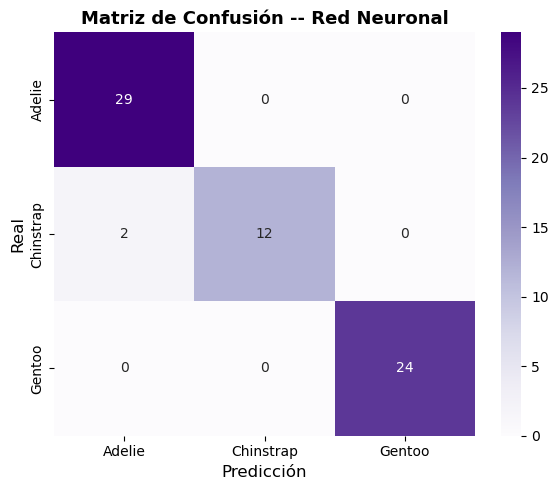


📌 ¿Cómo leer la matriz de confusión?
   La diagonal principal = predicciones correctas.
   Valores fuera de la diagonal = errores (confusión entre clases).
   Total aciertos: 65/67 (97.0%)
   - Adelie: 29 correctos, 0 errores
   - Chinstrap: 12 correctos, 2 errores
   - Gentoo: 24 correctos, 0 errores


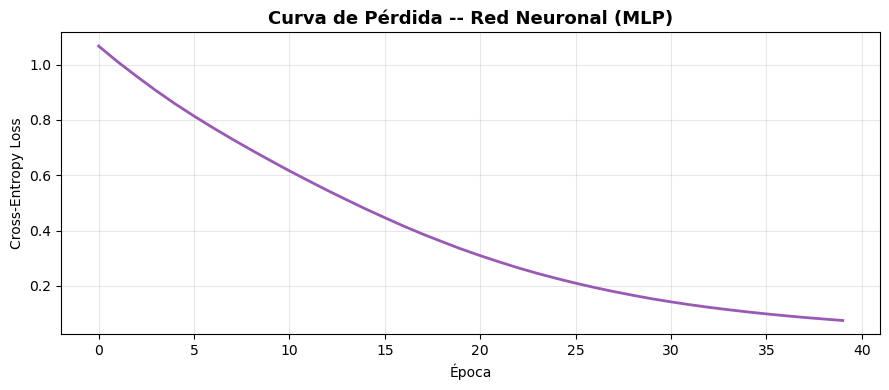

=== Como leer la curva de perdida? ===
El eje X = epocas (pasadas por los datos de entrenamiento).
El eje Y = error (menor es mejor).

Una curva que desciende y se estabiliza = entrenamiento saludable.
Si no baja o sube = el modelo no aprende; revisar
hiperparametros como el learning rate o la arquitectura.
revisar hiperparametros como el learning rate o la arquitectura.



In [26]:
# ── Entrenamiento Red Neuronal (MLP) ────────────────────────
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),  # 2 capas ocultas: 64 y 32 neuronas
    activation='relu',            # ReLU: f(x) = max(0, x)
    solver='adam',                # Optimizador Adam: adaptativo y eficiente
    max_iter=1000,
    random_state=42,
    early_stopping=True,          # Para si validación no mejora
    validation_fraction=0.1,      # 10% de train para monitoreo interno
    n_iter_no_change=20
)
mlp.fit(X_train, y_train)

y_pred_mlp = mlp.predict(X_test)

print_metrics(y_test, y_pred_mlp, "Red Neuronal (MLP)")
print(f"\n📐 Épocas hasta convergencia: {mlp.n_iter_}")
print(f"📐 Parámetros totales (pesos + biases): {sum(w.size for w in mlp.coefs_) + sum(b.size for b in mlp.intercepts_)}")

plot_confusion_matrix(y_test, y_pred_mlp, "Matriz de Confusión -- Red Neuronal")

# ── Curva de pérdida ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(mlp.loss_curve_, color='#9b59b6', linewidth=2)
ax.set_title('Curva de Pérdida -- Red Neuronal (MLP)', fontsize=13, fontweight='bold')
ax.set_xlabel('Época'); ax.set_ylabel('Cross-Entropy Loss')
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print(
    "=== Como leer la curva de perdida? ===\n"
    "El eje X = epocas (pasadas por los datos de entrenamiento).\n"
    "El eje Y = error (menor es mejor).\n\n"
    "Una curva que desciende y se estabiliza = entrenamiento saludable.\n"
    "Si no baja o sube = el modelo no aprende; revisar\n"
    "hiperparametros como el learning rate o la arquitectura.\n"
    "revisar hiperparametros como el learning rate o la arquitectura.\n"
)


---
## 📊 Bloque 8: Tabla Comparativa de Modelos

Ahora comparamos el desempeño de todos los modelos.

> La elección de modelo no siempre es sobre máxima precisión -- también importa la **interpretabilidad**, la **velocidad de entrenamiento** y si el problema requiere probabilidades.

📊 Tabla Comparativa de Todos los Modelos


,Accuracy,F1-Macro,Precision,Recall
Modelo,,,,
SVM (kernel RBF),0.9851,0.9827,0.9778,0.9885
Regresión Logística Multinomial,0.9851,0.9827,0.9778,0.9885
Red Neuronal (MLP),0.9701,0.9632,0.9785,0.9524
Árbol de Decisión,0.9552,0.9518,0.9468,0.9607
K-Means,0.7910,0.6019,0.5581,0.6667


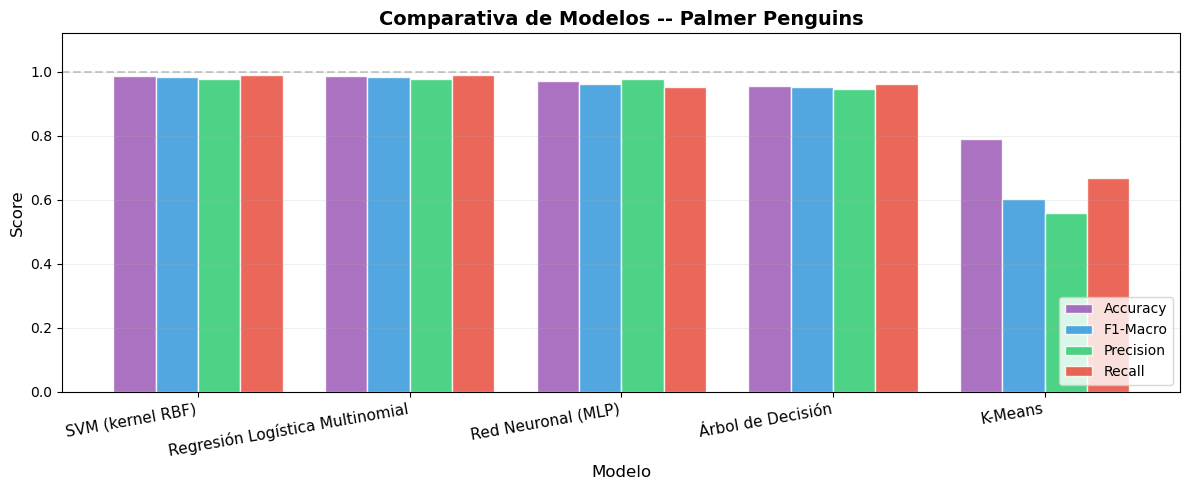


📌 El modelo con mayor accuracy fue: SVM (kernel RBF) (98.5%)
   El modelo con menor accuracy fue: K-Means (79.1%)

   Recuerda: accuracy alta no siempre significa mejor modelo.
   En un contexto real también evaluaríamos:
   - Tiempo de entrenamiento
   - Interpretabilidad para justificar decisiones
   - Comportamiento con datos desbalanceados


In [27]:
# ── Tabla comparativa ───────────────────────────────────────
df_res = pd.DataFrame(resultados).T
df_res.index.name = 'Modelo'
df_res = df_res.sort_values('Accuracy', ascending=False)

print("📊 Tabla Comparativa de Todos los Modelos")
display(df_res.style
        .background_gradient(cmap='Purples', axis=0)
        .format("{:.4f}")
        .set_caption("Métricas evaluadas en el conjunto de test (20% de los datos)"))

# ── Gráfica de barras ────────────────────────────────────────
metricas = ['Accuracy', 'F1-Macro', 'Precision', 'Recall']
colors   = ['#9b59b6', '#3498db', '#2ecc71', '#e74c3c']
x     = np.arange(len(df_res))
width = 0.2

fig, ax = plt.subplots(figsize=(12, 5))
for i, (metrica, color) in enumerate(zip(metricas, colors)):
    ax.bar(x + i*width, df_res[metrica], width, label=metrica,
           color=color, alpha=0.85, edgecolor='white')

ax.set_xlabel('Modelo', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Comparativa de Modelos -- Palmer Penguins', fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(df_res.index, rotation=10, ha='right', fontsize=11)
ax.legend(loc='lower right')
ax.set_ylim(0, 1.12)
ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.4)
ax.grid(True, alpha=0.2, axis='y')
plt.tight_layout(); plt.show()

# ── Análisis narrativo ───────────────────────────────────────
mejor = df_res['Accuracy'].idxmax()
peor  = df_res['Accuracy'].idxmin()
print(f"\n📌 El modelo con mayor accuracy fue: {mejor} ({df_res.loc[mejor,'Accuracy']:.1%})")
print(f"   El modelo con menor accuracy fue: {peor} ({df_res.loc[peor,'Accuracy']:.1%})")
print("\n   Recuerda: accuracy alta no siempre significa mejor modelo.")
print("   En un contexto real también evaluaríamos:")
print("   - Tiempo de entrenamiento")
print("   - Interpretabilidad para justificar decisiones")
print("   - Comportamiento con datos desbalanceados")

---
## 🔮 Bloque 9: Demo de Inferencia

Demostramos que los modelos funcionan con datos completamente nuevos.

> 🐧 **Pingüino de prueba:**  
> Isla: Dream - Pico: 46mm largo, 15mm profundo - Aleta: 215mm - Masa: 4,800g - Sexo: Macho  
> *(características típicas de Gentoo)*

In [28]:
# ── Pingüino nuevo ──────────────────────────────────────────
nuevo_raw = {
    'bill_length_mm': 46.0, 'bill_depth_mm': 15.0,
    'flipper_length_mm': 215.0, 'body_mass_g': 4800.0,
    'island_Biscoe': 0, 'island_Dream': 1, 'island_Torgersen': 0,
    'sex_Female': 0, 'sex_Male': 1,
}

X_nuevo        = pd.DataFrame([nuevo_raw])[feature_names].values.astype(float)
X_nuevo_scaled = scaler.transform(X_nuevo)

# ── Predicciones ─────────────────────────────────────────────
print("🐧 Predicciones para el pingüino nuevo")
print("="*65)

# K-Means (sin probabilidades directas)
cluster_nuevo  = kmeans.predict(X_nuevo_scaled)[0]
especie_kmeans = class_names[label_map.get(int(cluster_nuevo), int(cluster_nuevo))]
print(f"  {'K-Means':<30}: Cluster {cluster_nuevo} -> {especie_kmeans}")

# Modelos con probabilidades
modelos_prob = {
    "SVM (kernel RBF)":          svm,
    "Árbol de Decisión":         arbol,
    "Regresión Logística (RLM)": rlm,
    "Red Neuronal (MLP)":        mlp,
}

pred_rows = []
for nombre, modelo in modelos_prob.items():
    pred  = modelo.predict(X_nuevo_scaled)[0]
    proba = modelo.predict_proba(X_nuevo_scaled)[0]
    clase = class_names[pred]
    p_str = "  |  ".join([f"{class_names[i]}: {proba[i]:.1%}" for i in range(3)])
    print(f"  {nombre:<30}: {clase:<12}  [{p_str}]")
    pred_rows.append({'Modelo': nombre, 'Predicción': clase,
                      **{class_names[i]: f"{proba[i]:.1%}" for i in range(3)}})

print("="*65)
print("\n📋 Tabla de probabilidades:")
display(pd.DataFrame(pred_rows).set_index('Modelo'))

🐧 Predicciones para el pingüino nuevo
  K-Means                       : Cluster 2 -> Adelie
  SVM (kernel RBF)              : Adelie        [Adelie: 42.3%  |  Chinstrap: 36.8%  |  Gentoo: 20.8%]
  Árbol de Decisión             : Gentoo        [Adelie: 0.0%  |  Chinstrap: 0.0%  |  Gentoo: 100.0%]
  Regresión Logística (RLM)     : Gentoo        [Adelie: 5.0%  |  Chinstrap: 31.2%  |  Gentoo: 63.8%]
  Red Neuronal (MLP)            : Gentoo        [Adelie: 36.4%  |  Chinstrap: 25.0%  |  Gentoo: 38.7%]

📋 Tabla de probabilidades:


,Predicción,Adelie,Chinstrap,Gentoo
Modelo,,,,
SVM (kernel RBF),Adelie,42.3%,36.8%,20.8%
Árbol de Decisión,Gentoo,0.0%,0.0%,100.0%
Regresión Logística (RLM),Gentoo,5.0%,31.2%,63.8%
Red Neuronal (MLP),Gentoo,36.4%,25.0%,38.7%


---
## ✅ Bloque 10: Conclusiones

### Resumen

| Modelo | Supervisado | Interpretable | Probabilidades | Complejidad |
|--------|:-----------:|:-------------:|:--------------:|:-----------:|
| K-Means | ❌ | ⚠️ clusters | ❌ | ⬇️ Baja |
| SVM | ✅ | ❌ | ✅ | ⬆️ Media |
| Árbol | ✅ | ✅✅ | ⚠️ aprox. | ⬇️ Baja |
| RLM | ✅ | ✅ | ✅✅ | ⬇️ Baja |
| MLP (Neurona) | ✅ | ❌ | ✅ | ⬆️⬆️ Alta |

In [30]:
print("""
================ CONCLUSIONES GENERALES =================

El proyecto aplicó técnicas de análisis exploratorio y modelos de Machine Learning progresivamente más complejos para clasificar especies de pingüinos.

HALLAZGOS PRINCIPALES
--------------------------------------------------------

1. El EDA reveló que las tres especies presentan diferencias claras en variables físicas:

     - body_mass_g y flipper_length_mm -> mejor para Gentoo
     - bill_length_mm -> diferencia Chinstrap de Adelie

2. Existe correlación positiva entre masa corporal y longitud de aleta, información que los modelos supervisados aprovechan bien.

3. K-Means logró separar los datos razonablemente bien de forma no supervisada, confirmando que las especies son distinguibles por sus features físicas.

4. Los modelos supervisados mejoran consistentemente sobre K-Means al incorporar las etiquetas reales.

5. La Regresión Logística ofrece el mejor balance entre precisión, probabilidades calibradas e interpretabilidad.

6. La Red Neuronal (MLP) es el modelo más flexible, capaz de capturar relaciones no lineales entre variables.

CONCLUSIÓN FINAL
--------------------------------------------------------

El dataset Palmer Penguins es adecuado para clasificación supervisada:
   -las especies tienen características físicas diferenciables que los modelos pueden aprender con alta precisión, y el recorrido progresivo permite justificar cada incremento de complejidad.

========================================================
""")


================ CONCLUSIONES GENERALES =================

El proyecto aplicó técnicas de análisis exploratorio y modelos de Machine Learning progresivamente más complejos para clasificar especies de pingüinos.

HALLAZGOS PRINCIPALES
--------------------------------------------------------

1. El EDA reveló que las tres especies presentan diferencias claras en variables físicas:

     - body_mass_g y flipper_length_mm -> mejor para Gentoo
     - bill_length_mm -> diferencia Chinstrap de Adelie

2. Existe correlación positiva entre masa corporal y longitud de aleta, información que los modelos supervisados aprovechan bien.

3. K-Means logró separar los datos razonablemente bien de forma no supervisada, confirmando que las especies son distinguibles por sus features físicas.

4. Los modelos supervisados mejoran consistentemente sobre K-Means al incorporar las etiquetas reales.

5. La Regresión Logística ofrece el mejor balance entre precisión, probabilidades calibradas e interpretabilid